In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [8]:
# Useful defs

# check distance
def chk_dist( pos, targ_pos):
    dx = abs(pos[0] - targ_pos[0])
    dy = abs(pos[1] - targ_pos[1])

    dist = sqrt( dx**2 + dy**2 )
    return dist

# grid to array position 
def grid_to_array_pos( gp_x, gp_y, height ):
    return (gp_y * height ) + gp_x

# draw array as grid
def draw_array_grid( bits, width, height):
    grid = np.array(bits).reshape(( width, height ))

    plt.imshow(grid, cmap='grey', vmin=0, vmax=1)
    plt.colorbar()   # Optional: show color scale
    plt.axis('off')
    plt.figure(figsize=(6, 6))
    plt.show()

def draw_grid( grid, cmap="grey" ):
    plt.imshow(grid, cmap=cmap, vmin=0, vmax=1)
    plt.colorbar()   #Optional: show color scale
    plt.axis('off')
    plt.figure(figsize=(6, 6))
    plt.show()

def display_image( image, size=(6,6), color_map="gray", imin=0, imax=255, title=None):
    fig, ax = plt.subplots(figsize=size)
    ax.imshow( image, cmap=color_map)
    ax.axis('off')
    ax.set_title(title)#, fontsize=14)
    plt.show()


def display_images(image_list, name_list=None, size=(6, 3), cmap_list=None, _cmap ="gray"):
    num = len(image_list)

    plt.figure(figsize=size)

    for i in range(num):
        img = image_list[i]

        plt.subplot(1, num, i + 1)

        # Handle shape issues safely
        img = np.array(img)

        if cmap_list is None:
            if img.ndim == 3 and img.shape[-1] in (3, 4):
                plt.imshow(img)
            else:
                plt.imshow(np.squeeze(img), cmap= _cmap)
        else:
            plt.imshow(np.squeeze(img), cmap=cmap_list[i])

        if name_list is not None and i < len(name_list):
            plt.title(name_list[i])

        plt.axis('off')

    plt.tight_layout()
    plt.show()


In [9]:
# Start Conditions

size_x = 8
size_y = 8
size_xy = size_x*size_y

cell_size_x = size_x
cell_size_y = size_y

density_added = ( (size_x-2)**2 )*9
#World_grid  = ds_grid_create( size_x, size_y)

max_density_per_cell = 2
density = 20
collision_timescale = 0.8 # 0.8 - 2
time_steps = 1000

gx = 0
gy = 0

#	toplid_force
tvx = 0.1
tvy = 0

# sideid force
tvxb = 0
tvyb = 0


click_size = 1

directions = 9
reflect_guide  = [  0,		5,		6,		7,		 8,		 1,		 2,		3,		4 ]

f_x =		[  0,		 1,		  1,	 0,		 -1,	-1,		 -1,	 0,		1 ]
f_y =		[  0,		 0,		 -1,	 -1,	 -1,	 0,		  1,	 1,		1 ]

e =         [ [ 0,0],  [ 0,1],  [ -1,1], [ -1,0], [-1,-1],  [0,-1],  [ 1,-1],   [1,0], [ 1,1] ] # [f_y, f_x]

weights =   [ 4/9,		1/9,	1/36,	1/9,	1/36,	1/9,	 1/36,	1/9,	1/36 ]


In [ ]:
#region: Data representation

def create_sim_grid(size_x, size_y, size_d ):
    grid =  [0.0]*size_d
    for d in range( size_d):
        grid[ d] =  np.array( [0.0]*( size_x*size_y) ).reshape( size_y, size_x)     
    
    return grid

# optimizing#
World_grid =  create_sim_grid( size_x, size_y, directions)
s_temp_grid = create_sim_grid( size_x, size_y, directions)
c_temp_grid = create_sim_grid( size_x, size_y, directions)

#fill World_grid
for d in range( directions):
	World_grid[d][ 1: size_y-1, 1: size_x-1] = 1


# initialize density and velocity caches
display_grid = np.array( [0.0]*( size_xy) ).reshape( size_y, size_x)

density_grid =  np.array( [0.0]*( size_xy) ).reshape( size_y, size_x) 
velocity_grid_x =  np.array( [0.0]*( size_xy) ).reshape( size_y, size_x) 
velocity_grid_y =  np.array( [0.0]*( size_xy) ).reshape( size_y, size_x)
	
# initialize Obstacle grids
Obstacle_grid =  np.array( [0]*( size_xy) ).reshape( size_y, size_x) 
obstacle_cmap = ListedColormap( [ "black", "orange" ] )

for i in range( size_x ):
	for j in range( size_y ):
		if i == 0 or j == 0 or i == size_x-1 or j == size_y-1:
			Obstacle_grid[ j, i] = 0
	

#endregion



In [11]:
# Solver Functions
def point_in_rectangle( x, y, start_x, start_y, end_x, end_y):
    if ( x <= start_x or x >= end_x or y <= start_y or y >= end_y ):
        return False
    else:
        return True
    
def lengthdir_x( mag, lid_dir):
    return mag* math.cos( math.radians(lid_dir) )

def lengthdir_y( mag, lid_dir):
    return mag* math.sin( math.radians(lid_dir) )

def calculate_density_v2( i,j):	
    dsum = 0	
    dsum +=  World_grid[0][ j,i]
    dsum +=  World_grid[1][ j,i]
    dsum +=  World_grid[2][ j,i]
    dsum +=  World_grid[3][ j,i]
    dsum +=  World_grid[4][ j,i]
    dsum +=  World_grid[5][ j,i]
    dsum +=  World_grid[6][ j,i]
    dsum +=  World_grid[7][ j,i]
    dsum +=  World_grid[8][ j,i]
    return dsum
	

def collision_calc_v2( density, m, ux, uy, sq_ux, sq_uy ):
    cx = f_x[m]
    cy = f_y[m]
    wght = weights[m]
    
    cu_prod = cx*ux + cy*uy
    new_f = density * wght * ( 1 + 3*( cu_prod ) + 9*(cu_prod**2)/2 - 3*( sq_ux + sq_uy )/2 )
    return new_f

def reflect_particle_dir( dir_m):
	
					#			rest		r		ur		u		 ul		 l		dl		d		dr
					#			  0			1		2		3		 4		 5		 6		7		8
	#var reflect_guide  =		[ 0,		5,		6,		7,		 8,		 1,		 2,		3,		4 ]; 
    return reflect_guide[ dir_m]

	
def calculate_velocity_xy(cell, density):

    if( density < ( math.pow( math.e, -12) ) ):
        return 0, 0  # vx, vy ( safeguard)

    vx = 0
    vy = 0
    
    for m in range( 8+1):
        vx += cell[m]*f_x[m]
        vy += cell[m]*f_y[m]
    
    vx /= density
    vy /= density

    # Clamp for safety (optional)
    #vx = clamp(vx, -0.5, 0.5);
    #vy = clamp(vy, -0.5, 0.5);

    return vx, vy


def calculate_velocity_xy_v2( i,j, density):
    
    if ( density < math.pow( math.e, -12) ):
        return 0, 0 # vx, vy ( safeguard)

    vx = 0
    vy = 0
    for m in range( 8+1):
        vx += World_grid[m][ j, i] * f_x[m]
        vy += World_grid[m][ j, i] * f_y[m]
		
    
    vx /= density
    vy /= density

    # Clamp for safety (optional)
    #vx = clamp(vx, -0.5, 0.5);
    #vy = clamp(vy, -0.5, 0.5);

    return vx, vy



In [12]:
# Classical fluid simulation functions 1

def classical_stream( World_grids, Obstacle_grid):
    #region stream

	# cleanse temp grid
	for i in range( directions ):
		#s_temp_grid[i][ 0: size_y, 0:size_x ] = 0
		temp_grid = create_sim_grid( size_x, size_y, directions)

	# stream
	for i in range(size_x):
		for j in range(size_y):
			for m in range( directions):

				nx = i + f_x[m]
				ny = j + f_y[m]

				if point_in_rectangle( nx, ny, 0,0, size_x,size_y) and ( Obstacle_grid[ j, i] <= 0 ):
					temp_grid[m][ ny, nx] += World_grids[m][ j, i]
				else:
					opp = reflect_particle_dir( m)
					temp_grid[opp][ j, i] += World_grids[m][ j, i]
						
				
	#endregion
	return temp_grid


def density_velocity_buffer_solve( density_grid, velocity_grid_x, velocity_grid_y):
	
	density_grid[ 0: size_y, 0: size_x ] = 0
	velocity_grid_x[ 0: size_y, 0: size_x ] = 0
	velocity_grid_y[ 0: size_y, 0: size_x ] = 0

	for i in range( size_x):
		for j in range( size_y):
				
				cdensity =  calculate_density_v2( i,j)
				density_grid[ j, i] = cdensity
				b_vx, b_vy = calculate_velocity_xy_v2( i,j, cdensity)
				velocity_grid_x[ j, i] = b_vx
				velocity_grid_y[ j, i] = b_vy
	
	return density_grid, velocity_grid_x, velocity_grid_y


def classical_collision( World_grid, Obstacle_grid):

	# cleanse temp grid
	c_temp_grid = create_sim_grid( size_x, size_y, directions)


	# collision
	for i in range( size_x):
		for j in range( size_y):
			

			# Obstacles
			if ( Obstacle_grid[ j, i] > 0): # Visuaize Collission grid
				
				# Preserve wall populations
				for m in range( directions):
					c_temp_grid[m][ j,i] = 0 

				continue				
			
			
			# LID
			if ( j == size_y-2): #top
			#if ( i == 1) or ( i == size_x-2) or ( j == 1 ) or ( j == size_y-2):	

				ux = tvx
				uy = tvy
				
				#if ( i == size_x-2) :
				lid_dir = 0 
					
				if (i == 1):
					lid_dir = 90
				if (i == size_x-2):
					lid_dir = 270
				if (j == 1):
					lid_dir = 0
				if (j == size_y-2):
					lid_dir = 180
					
				ux = lengthdir_x( tvx, lid_dir)
				uy = lengthdir_y( tvx, lid_dir)
				
				
				rho = calculate_density_v2(i, j)

				sq_ux = ux * ux
				sq_uy = uy * uy

				for m in range( directions):
					omega_fac = 1 / collision_timescale
					feq = collision_calc_v2( rho, m, ux, uy, sq_ux, sq_uy)
					c_temp_grid[m][ j, i] =   (1 - omega_fac) * World_grid[m][ j, i] + omega_fac * feq

				
				continue


			# Normal Cells
			cdensity = calculate_density_v2( i,j);
		
			if ( cdensity > 0 ):	 # skip empty cells
				#if ( cdensity <= 0 ):	continue
			
				c_vel_x, c_vel_y = calculate_velocity_xy_v2( i,j, cdensity)

				# gravity;
				c_vel_x += gx
				c_vel_y += gy
			

				sq_cx = c_vel_x**2
				sq_cy = c_vel_y**2
				
				omega_fac = 1/collision_timescale
				
				for m in range( directions) :
					
					feq = collision_calc_v2( cdensity, m, c_vel_x, c_vel_y, sq_cx, sq_cy)
					c_temp_grid[m][ j, i] = (1 - omega_fac) * World_grid[m][ j, i] + omega_fac * feq
				
				
				
				display_grid[j, i] = 2*cdensity / density

	return c_temp_grid


def Print_fluid_state( s, directions, World_grid, velocity_grid_x, velocity_grid_y ):
	comb = 0
	vx_comb = 0
	vy_comb = 0

	for dp in range(directions):
		comb += sum( World_grid[dp].flatten() )
		
	vx_comb += sum( velocity_grid_x.flatten() )
	vy_comb += sum( velocity_grid_y.flatten() )
	print( "step: ", s, "density: ", comb, "velocity: ", vx_comb, vy_comb )


In [13]:
# Classical fluid simulation functions 2

def classical_move( World_grids):
    #region stream

	# cleanse temp grid
	temp_grid = create_sim_grid( size_x, size_y, directions)

	# stream
	for i in range(size_x):
		for j in range(size_y):
			for m in range( directions):

				nx = i + f_x[m]
				ny = j + f_y[m]

				if point_in_rectangle( nx, ny, 0,0, size_x,size_y):
					temp_grid[m][ ny, nx] += World_grids[m][ j, i]
				else:
					temp_grid[m][ j, i] += World_grids[m][ j, i]
						
				
	#endregion
	return temp_grid


def classical_boundary( World_grids, Obstacle_grid):


	temp_grid = create_sim_grid( size_x, size_y, directions)
		
	# boundary reflection
	for i in range( 0, size_x ):
		for j in range( 0, size_y ):
			for m in range( directions):
			
				cdensity = World_grids[m][j, i]
			
				if ( cdensity == 0):
					continue

				if ( Obstacle_grid[ j, i] > 0 ):# or  i== 0  or j== 0 or j==size_x-1 or j==size_y-1 ):
					opp = reflect_particle_dir( m)
					temp_grid[opp][ j, i] += cdensity # World_grids[m][ j, i]
				else:
					temp_grid[m][j, i] += cdensity #World_grids[m][j, i]



	#endregion
	return temp_grid


def classical_collision_v2( World_grid, Obstacle_grid):

	# cleanse temp grid
	c_temp_grid = create_sim_grid( size_x, size_y, directions)


	# collision
	for i in range( size_x):
		for j in range( size_y):
		
		
			# Obstacles
			for m in range( directions):
				if Obstacle_grid[j,i] > 0:
					opp = reflect_particle_dir(m)
					c_temp_grid[opp][j,i] += World_grid[m][j, i]
				else:
					c_temp_grid[m][j,i] += World_grid[m][j, i]		
						
			
			# LID
			if ( j == size_y-2): #top
			#if ( i == 1) or ( i == size_x-2) or ( j == 1 ) or ( j == size_y-2):	

				ux = tvx
				uy = tvy
				
				#if ( i == size_x-2) :
				lid_dir = 0 
					
				if (i == 1):
					lid_dir = 90
				if (i == size_x-2):
					lid_dir = 270
				if (j == 1):
					lid_dir = 0
				if (j == size_y-2):
					lid_dir = 180
					
				ux = lengthdir_x( tvx, lid_dir)
				uy = lengthdir_y( tvx, lid_dir)

				ux = np.clip(ux, -0.1, 0.1)
				uy = np.clip(uy, -0.1, 0.1)
				
				rho = calculate_density_v2(i, j)

				sq_ux = ux * ux
				sq_uy = uy * uy

				for m in range( directions):
					omega_fac = 1 / collision_timescale
					feq = collision_calc_v2( rho, m, ux, uy, sq_ux, sq_uy)
					c_temp_grid[m][ j, i] =   (1 - omega_fac) * World_grid[m][ j, i] + omega_fac * feq

				
				continue


			# Normal Cells
			cdensity = calculate_density_v2( i,j)
		
			if ( cdensity > 0 ):	 # skip empty cells
				#if ( cdensity <= 0 ):	continue
			
				c_vel_x, c_vel_y = calculate_velocity_xy_v2( i,j, cdensity)

				# gravity;
				c_vel_x += gx
				c_vel_y += gy
				
				c_vel_x = np.clip( c_vel_x, -0.1, 0.1)
				c_vel_y = np.clip( c_vel_y, -0.1, 0.1)

				sq_cx = c_vel_x**2
				sq_cy = c_vel_y**2
				
				omega_fac = 1/collision_timescale
				
				for m in range( directions) :
					
					feq = collision_calc_v2( cdensity, m, c_vel_x, c_vel_y, sq_cx, sq_cy)
					c_temp_grid[m][ j, i] = (1 - omega_fac) * World_grid[m][ j, i] + omega_fac * feq
				
				
				
				display_grid[j, i] = 2*cdensity / density

	return c_temp_grid


In [14]:
# Quantum Stream Functions
from numpy import pi
from numpy import sqrt

from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector


# region: Hibert Space Setup ( Mark hilbert space )
def create_possibility_space( n=3):
    bit_space = 2**n
    all_states = [ format(i, f'0{n}b') for i in range( bit_space)]

    #print( "possibility space: ", all_states)
    return all_states

bn_size = int( math.log2(size_xy) )
bit_space = size_xy

all_states = create_possibility_space( bn_size)

#endregion


def grid_to_quantum_state( grid_data, size):
    quantum_state_Version = np.array( grid_data, dtype=np.float64).reshape( size)

    #qsv_sqr = [ quantum_state_Version[i]**2 for i in range( size)]
    norm_sum = np.sum( quantum_state_Version**2 )#sum( qsv_sqr )
    if norm_sum == 0:
        return None, 0
    else:
        quantum_state_Version /= sqrt( norm_sum )
        return quantum_state_Version, norm_sum


def quantum_state_to_grid( state, normalize_factor,  size_x, size_y):
    res_grid = [0]*(size_x*size_y)

    init_qbit_size = int( math.log2(size_x*size_y) )
    label_ref = create_possibility_space( init_qbit_size)

    st_count = len( label_ref)

    for i in range( st_count):
        if label_ref[i] in state:
            res_grid[i] =  state[ label_ref[i] ]


    res_grid = [ (i* normalize_factor)**0.5 for i in res_grid ]
    res_grid = np.array( res_grid)

    
    res_grid = res_grid.reshape( size_y, size_x)

    return res_grid


def Measure_Probabilities( circ, method="qasm", reverse_bits=True ):

    if method=="qasm":
        backend = Aer.get_backend("qasm_simulator")

        compiled_circuit = transpile( circ, backend)

        job = backend.run(compiled_circuit, shots=1024)
        result = job.result()

        counts = result.get_counts()

        total_shots = sum(counts.values())
        prob_dict = { key: value/total_shots for key, value in counts.items() }

    else:
        backend = Aer.get_backend("statevector_simulator")

        qc_sv = circ.remove_final_measurements( inplace=False)

        compiled_circuit = transpile(qc_sv, backend)

        result = backend.run(compiled_circuit).result()

        statevector = result.get_statevector()

        # Convert StateVector to Probability dictionary
        prob_dict = Statevector( statevector).probabilities_dict()

    if reverse_bits:
        prob_dict = {k[::-1]: v for k, v in prob_dict.items()}


    return prob_dict

#Quantum Grid Movement 
def Quantum_move_xyaxis( circ, size, dir_x = 1, dir_y = 1):

    end_point = size
    control_bits = [ i for i in range(end_point) ]

    mid_point = end_point//2

    # Move X axis
    if dir_x > 0: # right
        for k in range( mid_point-1, 0, -1):
            circ.mcx( control_bits[0:k], k)
        circ.x(0)

    if dir_x < 0:
        circ.x(0) # left
        for k in range( 1, mid_point,  1):
            circ.mcx( control_bits[0:k], k)

    circ.barrier()

    #  Move Y axis
    if dir_y > 0: # down
        for k in range( end_point-1, mid_point,  -1):
            circ.mcx( control_bits[mid_point:k], k)
        circ.x(mid_point)

    if dir_y < 0: # up
        circ.x(mid_point)
        for k in range( mid_point+1, end_point):
            circ.mcx( control_bits[mid_point:k], k)
        

    circ.barrier()


def run_stream_quantum_circuit( quantum_state_data, size, move_x, move_y):
     
    csize = int( math.log2( size) ) #
    allbits = range( csize)

    circ = QuantumCircuit( csize, csize)

    circ.barrier()
    circ.initialize( quantum_state_data, allbits)

    circ.barrier()

    Quantum_move_xyaxis( circ, csize, move_x, move_y)

    circ.barrier()

    circ.measure( allbits, allbits )
    #circ.draw()

    return circ

# for removing border for quantum streaming operation to avoid wrapping
def seperate_borders( grid, dir):
    border = grid.copy()
    grid_shape = grid.shape
    g_sx = grid_shape[1]
    g_sy = grid_shape[0]
    g_s_xy = g_sx * g_sy

    border[ 1:g_sy-1, 1: g_sx-1 ] = 0.0

    not_border = grid.copy() #np.array( [0]*g_s_xy ).reshape( g_sy, g_sx )
    #not_border[ 1:g_sy-1, 1: g_sx-1 ] = grid[ 1:g_sy-1, 1: g_sx-1 ]
    

    border[0:g_sy, 0:g_sx] = 0.0 #clear
    #get direction vectors
    b_fx = f_x[dir]
    b_fy = f_y[dir]

    if (b_fx > 0):
        border[0:g_sy, g_sx-1] = grid[0: g_sy, g_sx-1]
        not_border[0:g_sy, g_sx-1] = 0
    if (b_fx < 0):
        border[0:g_sy, 0] = grid[0: g_sy, 0]
        not_border[0:g_sy, 0] = 0

    if (b_fy > 0):
        border[ g_sy-1, 0:g_sx] = grid[ g_sy-1, 0:g_sx]
        not_border[ g_sy-1, 0:g_sx] = 0

    if (b_fy < 0):
        border[ 0, 0:g_sx] = grid[ 0, 0:g_sx]
        not_border[ 0, 0:g_sx] = 0
    return not_border, border


# pad grid to match valid qiskit_initialize qubit size (power of 2)
def pad_grid( grid, offset):

    gshp = grid.shape
    nsx = gshp[1]*2
    nsy = gshp[0]*2
    nsxy = nsx*nsy

    new_grid = np.array( [0.0]*nsxy).reshape( nsy, nsx)
    new_grid[ offset: gshp[0]+offset, offset: gshp[1]+offset] = grid

    return new_grid, nsx

def extract_grid_from_padded_grid( pad_grid, offset, size_x, size_y):
    new_grid = np.array( [0.0]*size_x*size_y).reshape( size_y, size_x)

    new_grid = pad_grid[ offset: size_y+offset, offset: size_x+offset]

    return new_grid


def quantum_move_operation( World_grid, dir):


    dir_grid_data = World_grid.copy()

    gshp = dir_grid_data.shape
    gsize = gshp[0]*gshp[1]

    quantum_state_Version, norm_sum = grid_to_quantum_state( dir_grid_data, gsize)

    if ( norm_sum != 0 ):
        mx = f_x[dir]
        my = f_y[dir]
        qc = run_stream_quantum_circuit( quantum_state_Version, gsize, move_x = mx, move_y = my)

        qc_prob = Measure_Probabilities( qc, method="statevec", reverse_bits= False)
        
        dir_grid_data = quantum_state_to_grid( qc_prob, norm_sum, gshp[0], gshp[1])
        
    dir_grid_res = dir_grid_data

    return np.array( dir_grid_res)


def quantum_stream_operation( World_grid):

    res_grid = [] 
    pad_offset = 2
    for d in range( directions):
        
        dir_grid_data, dir_border_data  = seperate_borders( World_grid[d].copy(), d )

        dir_pad_grid_data, new_gsize = pad_grid( dir_grid_data, pad_offset)
        new_gsize_xy = new_gsize*new_gsize

        qcirc_res = quantum_move_operation( dir_pad_grid_data, d)
        dir_grid_data = extract_grid_from_padded_grid( qcirc_res, pad_offset, size_x, size_y)

        #merge borders
        merged_grid_data = dir_grid_data + dir_border_data 


        res_grid.append( merged_grid_data)

    return np.array( res_grid)



Quantum Stream Circuit: 

composed of: Initialize, x, cx and mcx gates

In [15]:
#Show Test Circuit
test_state, norm_fac = grid_to_quantum_state( World_grid[0].copy(), size_xy)

csize = int( math.log2( size_xy) )
circ = QuantumCircuit( csize, csize)



circ.initialize( test_state, range(csize) )
circ.barrier()
Quantum_move_xyaxis(circ, csize, 1,1)

circ.draw()

»
q_0: »
     »
q_1: »
     »
q_2: »
     »
q_3: »
     »
q_4: »
     »
q_5: »
     »
c: 6/»
     »
«     ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«q_0: ┤0                                                                                                                                                                                                                                                                                                                                                                     ├»
«     │                                                                                                                                                                                                                                                                                                                                                                      │»
«q_1: ┤1                                                                                                                                                                                                                                                                                                                                                                     ├»
«     │                                                                                                                                                                                                                                                                                                                                                                      │»
«q_2: ┤2                                                                                                                                                                                                                                                                                                                                                                     ├»
«     │  Initialize(0,0,0,0,0,0,0,0,0,0.16667,0.16667,0.16667,0.16667,0.16667,0.16667,0,0,0.16667,0.16667,0.16667,0.16667,0.16667,0.16667,0,0,0.16667,0.16667,0.16667,0.16667,0.16667,0.16667,0,0,0.16667,0.16667,0.16667,0.16667,0.16667,0.16667,0,0,0.16667,0.16667,0.16667,0.16667,0.16667,0.16667,0,0,0.16667,0.16667,0.16667,0.16667,0.16667,0.16667,0,0,0,0,0,0,0,0,0) │»
«q_3: ┤3                                                                                                                                                                                                                                                                                                                                                                     ├»
«     │                                                                                                                                                                                                                                                                                                                                                                      │»
«q_4: ┤4                                                                                                                                                                                                                                                                                                                                                                     ├»
«     │                                                                                                                                                                                                                     

Quantum Stream lbm

In [16]:
# Fluid Simulation using Quantum Streaming step
for s in range( 30):

	#fluid_state

	#classical Density and Velocity buffer
	density_grid, velocity_grid_x, velocity_grid_y = density_velocity_buffer_solve( density_grid, velocity_grid_x, velocity_grid_y)
	Print_fluid_state( s, directions, World_grid.copy(), velocity_grid_x.copy(), velocity_grid_y.copy())

	
	#Quantum Stream
	World_grid = quantum_stream_operation( World_grid)

	# Boundary Conditions step
	World_grid = classical_boundary( World_grid, Obstacle_grid)
	

	World_grid = classical_collision_v2(World_grid, Obstacle_grid)


	#region Quantum Collision

step:  0 density:  324.0 velocity:  0.0 0.0
step:  1 density:  324.0 velocity:  -1.0000000000000004 -1.0
step:  2 density:  325.2388888888888 velocity:  -0.8179717226590769 -1.0362942575779883
step:  3 density:  325.2388888888889 velocity:  -1.0395947217540558 -1.3867472704796446
step:  4 density:  325.23888888888877 velocity:  -1.0773410337728024 -1.6391324025898448
step:  5 density:  325.2388888888888 velocity:  -1.0889764806141908 -1.7565008145827434
step:  6 density:  325.2388888888888 velocity:  -1.1010250674127937 -2.0687087139226437
step:  7 density:  325.23888888888877 velocity:  -1.119193617752197 -2.2710932707221745
step:  8 density:  325.2388888888887 velocity:  -1.110610039724009 -2.3088149997672125
step:  9 density:  325.2388888888886 velocity:  -1.079238870927175 -2.1523490941579695
step:  10 density:  325.23888888888865 velocity:  -1.0259690229332121 -1.8761457051709756
step:  11 density:  325.2388888888886 velocity:  -0.9560769216150752 -1.4842300191723294
step:  12 den

In [17]:
def draw_stream( size_x, size_y, velocity_grid_x, velocity_grid_y, ):
    nx, ny = size_x-2, size_y-2 
    x = np.arange(nx)
    y = np.arange(ny)
    X, Y = np.meshgrid(x, y)

    ux_2d = velocity_grid_x[ 1:ny+1, 1:nx+1, ]
    uy_2d = velocity_grid_y[ 1:ny+1, 1:nx+1, ]
    speed = np.sqrt( ux_2d**2 + uy_2d**2 )
    vmin, vmax = 0.0, float(speed.max())

    plt.figure(figsize=(3.0, 3.0), dpi=300)
    strm = plt.streamplot(
        X, Y, ux_2d, uy_2d,
        density=1.0,              # streamline density; tweak for aesthetics
        color=speed,
        cmap='jet',
        linewidth=1.15,
        arrowsize=1.2,
        minlength=0.1,
    )

    # colorbar like the paper (|u|)
    cb = plt.colorbar(strm.lines, pad=0.02)
    cb.set_label(r'$|u|$', rotation=0, labelpad=12)

    # axes styling to resemble the figure
    plt.xlim(0, nx-1)
    plt.ylim(0, ny-1)
    plt.xlabel(r'$x$')
    plt.ylabel(r'$y$')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

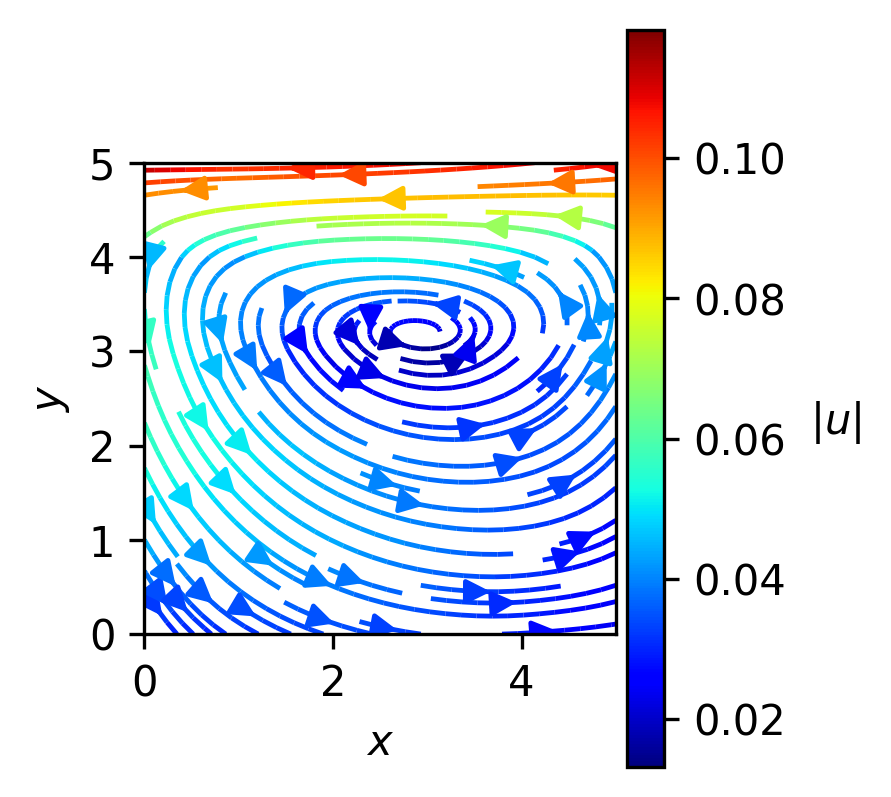

In [18]:
draw_stream( size_x, size_y, velocity_grid_x, velocity_grid_y)

Fully Classical lbm (Comparison)

In [19]:
# Full Classical Simulation

classical_world_grid = create_sim_grid( size_x, size_y, directions)

for k in range( directions):
	classical_world_grid[k][0:size_y, 0:size_x] = 1

classical_density_grid =  np.array( [0.0]*( size_xy) ).reshape( size_y, size_x) 
classical_velocity_grid_x =  np.array( [0.0]*( size_xy) ).reshape( size_y, size_x) 
classical_velocity_grid_y =  np.array( [0.0]*( size_xy) ).reshape( size_y, size_x)

for s in range(20):

	#fluid_state

	#classical Density and Velocity buffer
	classical_density_grid, classical_velocity_grid_x, classical_velocity_grid_y = density_velocity_buffer_solve( 
		classical_density_grid, 
		classical_velocity_grid_x, 
		classical_velocity_grid_y
		)
	
	Print_fluid_state( s, directions, classical_world_grid.copy(), classical_velocity_grid_x.copy(), classical_velocity_grid_y.copy())


	# Boundary Conditions step
	
	# classical Streaming
	classical_world_grid = classical_stream( classical_world_grid, Obstacle_grid)

	#region  classical collision
	classical_world_grid = classical_collision( classical_world_grid, Obstacle_grid)
	

	


step:  0 density:  576.0 velocity:  -0.37268811844848915 -0.3899953798324258
step:  1 density:  262.54861111111035 velocity:  -0.37268811844848915 -0.3899953798324258
step:  2 density:  340.91145833333263 velocity:  -0.37268811844848915 -0.3899953798324258
step:  3 density:  321.3207465277771 velocity:  -0.37268811844848915 -0.3899953798324258
step:  4 density:  326.21842447916595 velocity:  -0.37268811844848915 -0.3899953798324258
step:  5 density:  324.99400499131883 velocity:  -0.37268811844848915 -0.3899953798324258
step:  6 density:  325.3001098632805 velocity:  -0.37268811844848915 -0.3899953798324258
step:  7 density:  325.2235836452902 velocity:  -0.37268811844848915 -0.3899953798324258
step:  8 density:  325.2427151997877 velocity:  -0.37268811844848915 -0.3899953798324258
step:  9 density:  325.2379323111634 velocity:  -0.37268811844848915 -0.3899953798324258
step:  10 density:  325.2391280333195 velocity:  -0.37268811844848915 -0.3899953798324258
step:  11 density:  325.2388

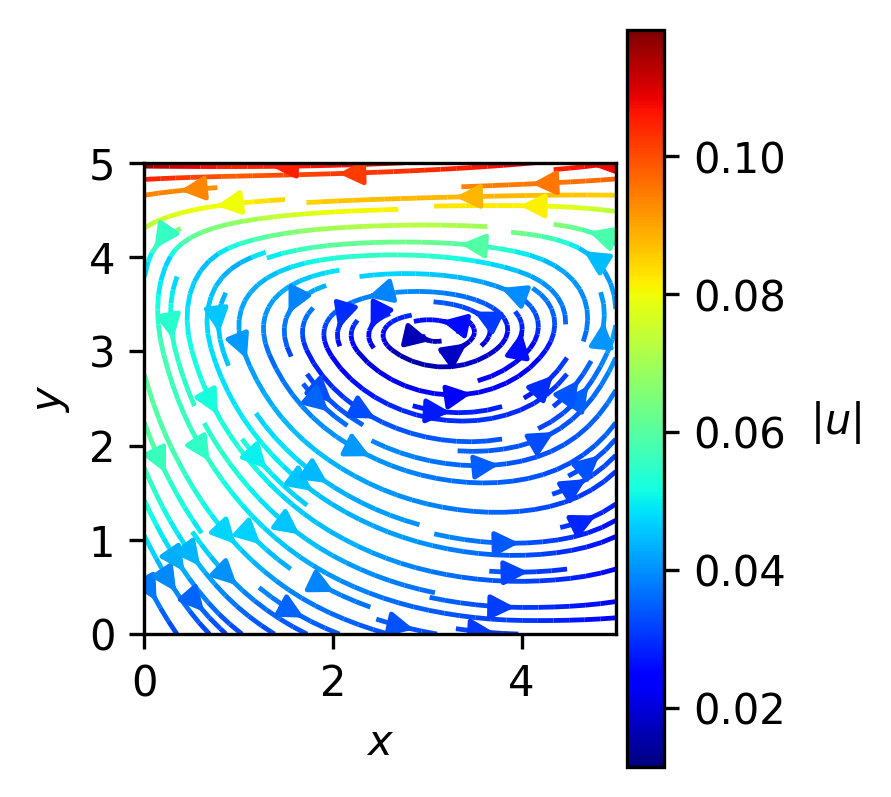

In [20]:
draw_stream( size_x, size_y, classical_velocity_grid_x, classical_velocity_grid_y)